# Text as Data Lab 6: Dependency Parsing

In this week's lab, we'll explore how shift-reduce parsing works

The aims of this lab are:
- Implement the three actions of a shift-reduce parser
- Figure out the steps to parse a few example sentences
- See how spaCy can do dependency parsing

**Before you start, save a copy of this lab to your drive using "File > Save a Copy in Drive".** If you skip this step, you may lose progress that you have made (e.g., if you close the browser tab or your computer crashes).

## Setting up the labtest function

As with earlier labs, we'll use a `labtest` function so that you can check your code. You need to install and load it with the code below.

In [ ]:
# Installs the labtest system and loads the tests for this specific lab

!pip install -U git+https://github.com/jakelever/glasgowcs_labtest.git
from glasgowcs_labtest.textasdata.lab6 import labtest

## Example of a dependency parse

In the lecture, we saw that a dependency parse is a way of connecting pairs of tokens in a sentence and identifying their purpose. The example below shows `Sally` is the subject and `movies` is the object of the verb `likes`. Each edge is labelled with its purpose. A common set of labels with their explanations can be explored at:
https://universaldependencies.org/u/dep/all.html

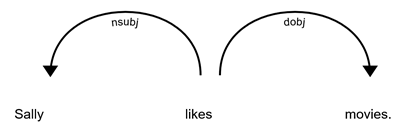

Each token has at most one edge pointing at it (from a node called its head node). So the head token of `Sally` is `likes`. The typical way to store this information is that each token stores the index of its head token and the dependency relation label (e.g. `nsubj`).

Let's see what the sentence above could be represented as. We include a special ROOT token. Often this points towards the main verb of sentence. Each tuple of four elements has: the index of the token, the text of the token, the index of the head token and the dependency relation label.

In [ ]:
tokens = [
  (0, 'ROOT', None, None),
  (1, 'Sally', 2, 'nsubj'),
  (2, 'likes', 0, 'ROOT'),
  (3, 'movies', 2, 'dobj'),
  (4, '.', 2, 'punct')
]

In the example above, the token with `index=3` is `movies` and its head node is `likes` at `index=2` with dependency relation `dobj` which is direct object.

## Visualising dependency parses

It can be nice to visualise these things instead of looking at indices. We'll provide some code for doing this with the [pydot library](https://pypi.org/project/pydot/) which provides a nice wrapper for [Graphviz](https://www.graphviz.org/) and the [DOT language](https://en.wikipedia.org/wiki/DOT_(graph_description_language)).

Try running the code below to draw the dependency graph outlined above for the text `Sally likes movies.` DOT/Graphviz are powerful tools for visualising networks of data. You don't need to dig into how the `display_parse` function works but it may be a useful example for other work.

In [ ]:
import pydot
from IPython.display import Image, display

def display_parse(tokens):
  """
  Function to create a visual representation of a dependency parse using pydot
  """
  # Create a directed graph with some other layout settings
  graph = pydot.Dot("my_graph", graph_type="digraph", layout="neato", splines="ortho")
  for i,token,head_index,label in tokens:
    # Add a node for each token with text and location
    graph.add_node( pydot.Node(i, label=token, pos=f"{2*i},1!") )
    # Add the dependency graph edge from this node to its head
    if i > 0:
      graph.add_edge( pydot.Edge(head_index, i, label=label) )

  # Render the graph to PNG and output to the notebook
  display(Image(graph.create_png()))

display_parse(tokens)

Let's try running it on a longer sentence as below.

In [ ]:
quick_brown_fox_tokens = [
  (0, 'ROOT', 0, None),
  (1, 'The', 4, 'det'),
  (2, 'quick', 4, 'amod'),
  (3, 'brown', 4, 'amod'),
  (4, 'fox', 5, 'nsubj'),
  (5, 'jumps', 0, 'ROOT'),
  (6, 'over', 5, 'prep'),
  (7, 'the', 9, 'det'),
  (8, 'lazy', 9, 'amod'),
  (9, 'dog', 6, 'pobj')
]

display_parse(quick_brown_fox_tokens)

Cool. That provides a visualisation of our target parse for the sentence `The quick brown fox jumps over the lazy dog`.

## Visualising shift-reduce parsing

In the lecture, we explored the idea of shift-reduce parsing to create the edges for the dependency path. The shift-reduce system involves creating a stack, buffer and list of edges for the parse.

The stack and buffer can be represented as lists of tokens with their indices. Plus the list of edges can be pairs of indices indicating an edge from one token index to another.

Let's go back to the tokens for `"Sally likes movies."` Here's an example state for the stack, buffer and edges. It's a few steps into the parse shown in the lecture, just after adding the right arc between `likes` and `movies`.

In [ ]:
stack = [ tokens[0], tokens[1], tokens[2] ] # ROOT, Sally, likes (movies has been removed from the stack)
buffer = [ tokens[4] ] # .
edges = [ (2,3) ] # From likes -> movies

It's hard to quickly see what's going on. So let's use `pydot` again to visualise it. Below is a function called `display_state` that will create a nice diagram of the state of the state, buffer, etc. Again, you shouldn't have to dig into this function, but could customise it if you'd like.

In [ ]:
def display_state(tokens, stack, buffer, edges):
  """
  Function to create a visual representation of a shift-reduce parse state
  """
  # Create a directed graph with some other layout settings
  graph = pydot.Dot("my_graph", graph_type="digraph", layout="neato", splines="ortho")
  for token in tokens:
    index,text = token[0], token[1]
    # Decide the color of the background depending on whether it's in the stack, buffer, etc
    color = '#fc9f9f' if token in stack else '#8cf4ff' if token in buffer else 'lightgrey'
    # Add the node with a positional offset for things not in the stack/buffer
    graph.add_node( pydot.Node(index, label=text, pos=f"{2*index},{1 if token in (stack+buffer) else 0.5}!", style="filled", color=color) )

  # Add the arcs (edges in the dependency parse)
  for a,b in edges:
    graph.add_edge( pydot.Edge(a, b) )

  # Render the graph to PNG and output to the notebook
  display(Image(graph.create_png()))

display_state(tokens, stack, buffer, edges)

That should have displayed the state of the parse a bit more clearly. The tokens in red are in the stack. The tokens in light blue are in the buffer. And arcs are shown between the tokens.

Let's visualise a few other states. The initial state for parsing has the ROOT token in the stack, all other tokens in the buffer and no edges yet:

In [ ]:
stack = tokens[:1] # ROOT
buffer = tokens[1:] # Sally, likes, movies .
edges = []

display_state(tokens, stack, buffer, edges)

Doing several shift actions would move more tokens onto the stack and off the buffer:

In [ ]:
stack = tokens[:3] # ROOT, Sally, likes
buffer = tokens[3:] # movies, .
edges = []

display_state(tokens, stack, buffer, edges)

Doing a left-arc action at that point would create an edge from `likes` to `Sally` and remove `Sally` from the stack.

In [ ]:
stack = [tokens[0], tokens[2]] # ROOT, likes
buffer = tokens[3:] # movies, .
edges = [(2,1)] # likes -> Sally

display_state(tokens, stack, buffer, edges)

However, all these examples have involved manually figuring out what the stack, buffer and edges would be. It would be nice to have some code that could run the various actions and update the stack, buffer and edges. Let's investigate that:

## Implementing the actions

Our shift-reduce parser will have three possible actions.

- **Shift (s):** Remove the first element of the buffer and add it to the end of the stack
- **Left Arc (l):** Create an edge from the final element of the stack towards the second last element of the stack. Then remove the second last element from the stack.
- **Right Arc (r):** Create an edge from the second last element of the stack towards the last element of the stack. Then remove the last element from the stack.

### Shift

- **Shift (s):** Remove the first element of the buffer and add it to the end of the stack

**Exercise:** Write a function `shift` that takes the stack and buffer lists and executes the shift operation **in-place**. This means that operations should be done on the lists passed into the function and nothing should be returned.

In [ ]:
def shift(stack, buffer):
  # your code!

stack = tokens[:3] # ROOT, Sally, likes
buffer = tokens[3:] # movies, .
shift(stack, buffer)
print(f"{stack=} {buffer=}")

Your function should have moved `movies` from the buffer to the stack.

We can visualise what it's doing using the `display_state` function. Here we would expect it to move `likes` from the buffer onto the stack.

In [ ]:
stack = tokens[:3] # ROOT, Sally, likes
buffer = tokens[3:] # movies, .
edges = []

# Visualise before the action
display_state(tokens, stack, buffer, edges)

shift(stack, buffer)

# Visualise after the action
display_state(tokens, stack, buffer, edges)

And it's always good to run a test on the function:

In [ ]:
labtest(shift)

### Left Arc

- **Left Arc (l):** Create an edge from the final element of the stack towards the second last element of the stack. Then remove the second last element from the stack.

**Exercise:** Write a function `left_arc` that takes the stack and edge lists and executes the left-arc operation **in-place**.

In [ ]:
def left_arc(stack, edges):
  # your code!

stack = tokens[:3] # ROOT, Sally, likes
edges = []
left_arc(stack, edges)
print(f"{stack=} {edges=}")

Now this should have created an edge from `likes` to `Sally` and removed `Sally` from the stack.

Let's visualise what it's doing:

In [ ]:
stack = tokens[:3]
buffer = tokens[3:]
edges = []

# Visualise before the action
display_state(tokens, stack, buffer, edges)

left_arc(stack, edges)

# Visualise after the action
display_state(tokens, stack, buffer, edges)

And another test:

In [ ]:
labtest(left_arc)

### Right Arc

- **Right Arc (r):** Create an edge from the second last element of the stack towards the last element of the stack. Then remove the last element from the stack.


**Exercise:** Write a function `right_arc` that takes the stack and edge lists and executes the right arc operation **in-place**.

In [ ]:
def right_arc(stack, edges):
  # your code!

stack = tokens[:3] # ROOT, Sally, likes
edges = []
right_arc(stack, edges)
print(f"{stack=} {edges=}")

Your `right_arc` function should have created an edge from `Sally` to `likes` and removed `likes` from the stack.

Let's visualise the action:

In [ ]:
stack = tokens[:3]
buffer = tokens[3:]
edges = []

# Visualise before the action
display_state(tokens, stack, buffer, edges)

right_arc(stack, edges)

# Visualise after the action
display_state(tokens, stack, buffer, edges)

In [ ]:
labtest(right_arc)

### Switch between actions

We're going to want to run lots of actions depending on an input string of actions. Let's break that down a little.

**Exercise:** Write a function `run_action` that takes in a single character `action` (s/l/r for the three possible actions) along with the `stack`, `buffer` and `edges` lists. It should then run the corresponding action of shift (`s`), left_arc (`l`) and right_arc(`r`). And again, everything should be done **in-place**.

In [ ]:
def run_action(action, stack, buffer, edges):
  # your code!

stack = tokens[:3] # ROOT, Sally, likes
buffer = tokens[3:] # movies, .
edges = []
run_action('r', stack, buffer, edges) # Run a right_arc action
print(f"{stack=} {buffer=} {edges=}")

We can use the code to visualise a couple actions using the `run_action` function. This will run the shift action and then the right arc action.

In [ ]:
stack = tokens[:3]
buffer = tokens[3:]
edges = []

# Visualise before the action
display_state(tokens, stack, buffer, edges)

run_action('s', stack, buffer, edges)

# Visualise after shift action
display_state(tokens, stack, buffer, edges)

run_action('r', stack, buffer, edges)

# Visualise after the right arc action
display_state(tokens, stack, buffer, edges)

And good to check with labtest:

In [ ]:
labtest(run_action)

## Running a series of actions on text

Now we can run a bunch of actions and visualise them. Here's a function `run_actions` that sets up the initial states for the stack, buffer and edges and runs a series of actions.


In [ ]:
def run_actions(tokens, actions):
  # Set and visualise initial stack, buffer and edges
  stack = tokens[:1]
  buffer = tokens[1:]
  edges = []
  display_state(tokens, stack, buffer, edges)

  # Run the actions and visualise them
  for action in actions:
    print(f'\n{action=}')
    run_action(action, stack, buffer, edges)
    display_state(tokens, stack, buffer, edges)


The input is the list of tokens and the series of actions as a string. For example, the string `"slsr"` would be a list of four actions: a shift, a left arc, a shift and then a right arc.

Let's see what that would do:

In [ ]:
run_actions(tokens, 'slsr')

Well that doesn't look like the parse that we want. Let's visualise the target parse again with `display_parse`.

In [ ]:
display_parse(tokens)

**Exercise:** Figure out the series of actions to parse the tokens and create the edges in the target parse above.

*Tip: There are four tokens (excluding the root) which means you will need to shift each one once, and add an arc for each one. So there will be eight total actions*

*Tip 2: We actually did this in the lecture, so you can always refer to that*

In [ ]:
run_actions(tokens, ?)

The final state of the edges should match with the target parse (except that there are no labels on the edges).

## Figure out the actions for a longer sentence

Let's do one more and make it a little more challenging. Recall the target parse for the text `The quick brown fox jumps over the lazy dog`

In [ ]:
display_parse(quick_brown_fox_tokens)

**Exercise:** Figure out the list of actions for `quick_brown_fox_tokens` to get to the target parse above

*Tip: As above, you will end up with twice the number of actions as tokens, so 18 actions*

In [ ]:
run_actions(quick_brown_fox_tokens, ?)

## Deciding on the optimal actions

An effective automatic parser uses machine learning to learn when it should shift, left arc or right arc. This involves getting a lot of hand-annotated parses, figuring out the full set of optimal actions and then training a system to decide the best one given the current stack/buffer/etc. We won't go into this in this lab and will instead see how spaCy does it.

## Using spaCy

spaCy uses [a shift-reduce parser](https://spacy.io/api/dependencyparser) as well that has been trained with lots of examples of text and target parses. Let's briefly see how to use it.

You first need to load up spaCy with a particular language, such as English below.

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')

The default parser will do dependency parsing. You can then access the index of the head token with `token.head.i` and the label of the dependency edge with `token.dep_` (note the extra underscore).

Let's see what that looks like for `"The quick brown fox jumps over the lazy dog"`

In [ ]:
parsed = nlp("The quick brown fox jumps over the lazy dog")

for token in parsed:
  print((token.text, token.head.i, token.dep_))

This looks similar to the representation that we used earlier in the lab. spaCy doesn't actually add a ROOT node, but the token that would connect to it has a 'ROOT' edge to itself. That's `jumps` in the parse above.

spaCy also offers a visualiser [displaCy](https://demos.explosion.ai/displacy) to output nice figures of their dependency path.

In [ ]:
from spacy import displacy
displacy.render(parsed, style="dep", jupyter=True)

These dependency paths can be use to identify subjects and objects of actions, modifiers of nouns and other important linguistic features that can be used for other tasks such as information extraction.

## End

This is the end of Lab 6. Let us know if you encounter any issues! Remember we are here to help!

In this lab, you...
- visualised dependency parses of a sentence
- implemented the key steps (shift, left arc & right arc) of a dependency parser
- manually dependency parsed some sentences
- uses spaCy to dependency parse

**Please submit your lab through Moodle. We don't mark the labs but it helps us to craft better labs in the future**

## Optional Extras

- Create another parse with spaCy and see if you can figure out the shift-reduce actions to recreate it.
- Play around with pydot. See what happens when you remove the [pos](https://graphviz.org/docs/attrs/pos/) parameter from the addNode commands. What about changing the [splines](https://graphviz.org/docs/attrs/splines/) parameter when the graph is created?